## SMBHB model 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: 
- Stochastic Quasar Variability
- Doppler boosting
- Gravitational self-lensing

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
from platosim.varsource    import SMBHB
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

---
## Model Spikey
---

We here verify that we can recreate the synthetic model light curve of Spikey using the constants and parameters from Hu+2020.

In [56]:
# Initialise model
dt   = 3600
tdur = 3 * ut.year()
time = np.arange(0, tdur, dt) * u.s
model = SMBHB(time, seed=123456789)

# Parameters
t0  = u.yr * 1.05
z  = 0.962
P  = u.yr * 1.144
M1 = 10**7.4 * u.M_sun                                                           
M2 = 10**6.7 * u.M_sun
I  = np.arccos(0.140) * u.rad
i  = np.pi/2 * u.rad - I
J  = np.pi / 4 * u.rad
e  = 0.524
w  = 1.477 * u.rad
alpha = 2.09
f_lum = 0.89

### QSO variability (red noise)

<IPython.core.display.Javascript object>


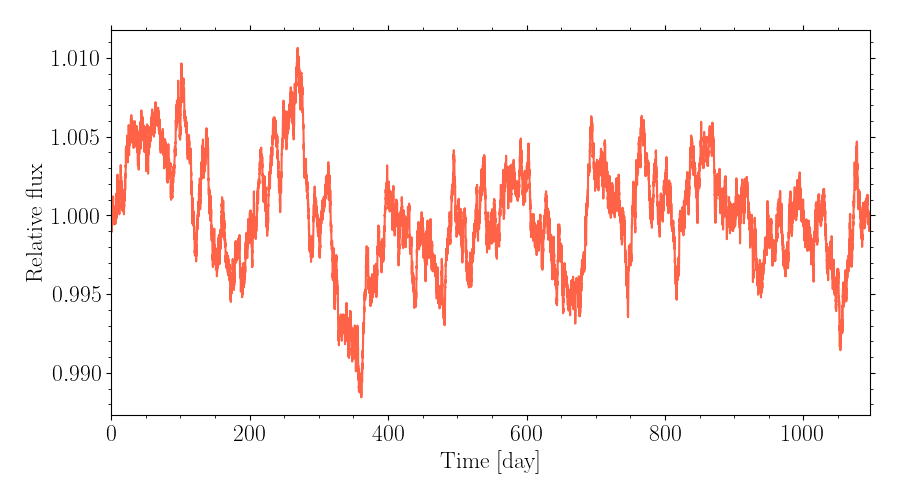

In [30]:
tau   = np.array([50]) * u.d
sigma = np.array([300]) # ppm
model.quasar_variability(tau, sigma, plot=True);

<IPython.core.display.Javascript object>


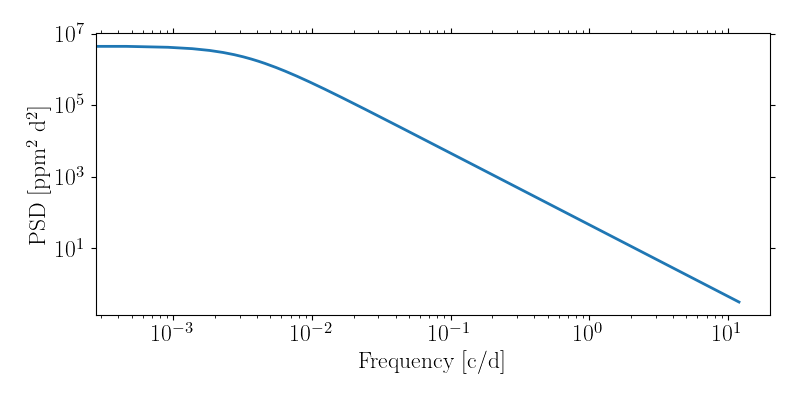

In [31]:
# Show Powerspectral density plot
Nfreq = time.shape[0]
freq = np.arange(float(Nfreq)) / (Nfreq-1) * 0.5 / (dt * u.s).to('d').value
PSD = ns.modelRedNoisePSD(freq, tau.to('d').value, sigma)

fig = plt.figure(figsize = (8, 4))
for i in range(len(tau)):
    plt.loglog(freq, PSD, lw=2)
plt.xlabel(r"Frequency [c/d]")
plt.ylabel(r"PSD [ppm$^2$ d$^2$]")
plt.tight_layout()
plt.show()

### Doppler boosting

Model parameters:
Time of ephemeris, t0              : 1.050 yr
Orbital period in rest frame, P    : 1.144 yr
Orbital period in obs. frame, T    : 2.245 yr
Mass total, M = (M1 + M2)          : 30.131 solMass x 1e6
Mass ratio, q = (M2 / M1)          : 0.1995
Inclination to LOS, i              : 81.95 deg
Eccentricity, e                    : 0.52
Argument of periapse, w            : 84.63 deg
Semi-major axis of binaries, a     : 340.37 AU
RV semi-amplitude of primary, K1   : 873.42 km / s
RV semi-amplitude of secondary, K2 : 4377.44 km / s


<IPython.core.display.Javascript object>


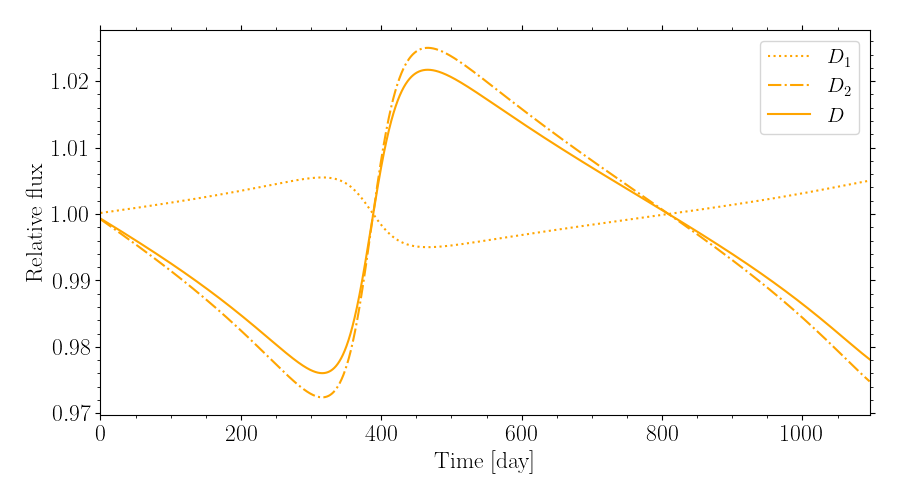

In [53]:
model.doppler_boosting(t0, z, P, M1, M2, I, e, w, alpha, f_lum, plot=True);

### Grantional lensing

Model parameters:
Time of ephemeris (lens of M2), t0 : 1.050 yr
Orbital period in rest frame, P    : 1.144 yr
Orbital period in obs. frame, T    : 2.245 yr
Mass total, M = (M1 + M2)          : 30.131 solMass x 1e6
Mass ratio, q = (M2 / M1)          : 0.1995
Inclination of orbits, I           : 81.95 deg
Inclination of mini-disc, J        : 45.00 deg
Semi-major axis of binaries, a     : 340.37 AU
Schwarchild radius primary, Rs1    : 106.63 solRad
Schwarchild radius secondary, Rs2  : 21.28 solRad
Max Einstein radius primary, Re1   : 18.37 AU
Max Einstein radius secondary, Re2 : 8.21 AU
3.2016806722689077
1.7893240825152128


<IPython.core.display.Javascript object>


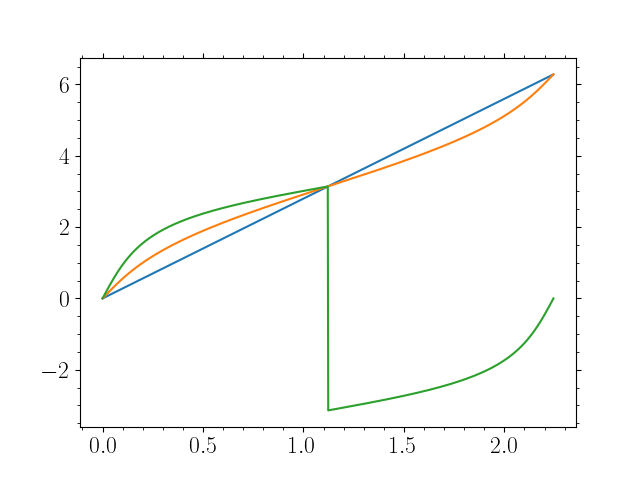

NameError: name 'exit' is not defined

In [78]:
model.gravitational_lensing(t0, z, P, M1, M2, I, e, w, J, plot=True);

### Combined model

<IPython.core.display.Javascript object>


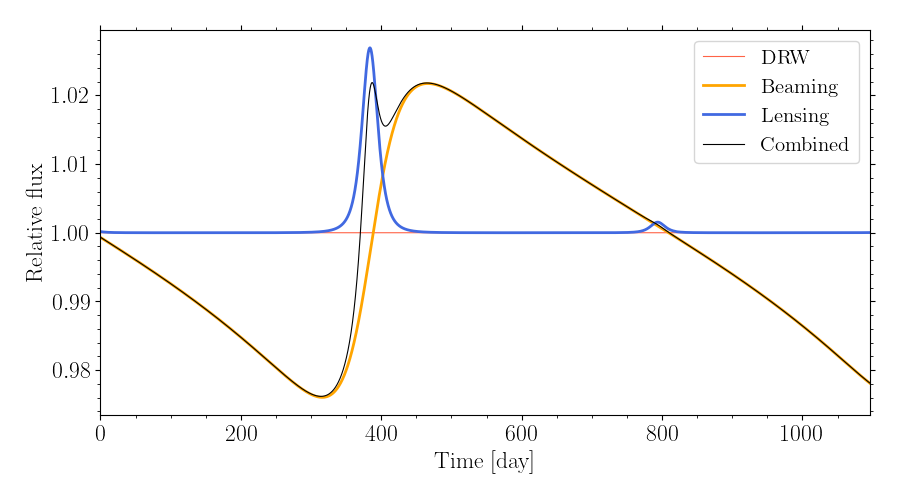

In [55]:
flux = model.evalPhysicalModel(plot=True)

## Example: Reproduce Hu+2020 (Fig. 4)

In [43]:
# Initialise model
dt   = 3600
tdur = ut.year() * 40
time = np.arange(0, tdur, dt) * u.s
model = SMBHB(time, seed=123456789)

# Parameters
t0 = 10 * u.yr
z = 0
P = 20 * u.yr
M1 = 5e8 * u.M_sun
M2 = 5e7 * u.M_sun
I = np.deg2rad(87) * u.rad
J = np.pi/2 * u.rad
alpha = 2.0
f_lum = 0.7

In [44]:
# Generate model with e = {0.001, 0.234, 0.467, 0.7}
e = 0.234
plot = False
w = np.deg2rad(0) * u.rad
model.doppler_boosting(t0, z, P, M1, M2, I, e, w, alpha, f_lum, plot=plot);
model.gravitational_lensing(t0, z, P, M1, M2, I, e, w, J, plot=plot);
flux_w000 = model.evalPhysicalModel(plot=plot)
w = np.deg2rad(90) * u.rad
model.doppler_boosting(t0, z, P, M1, M2, I, e, w, alpha, f_lum, plot=plot);
model.gravitational_lensing(t0, z, P, M1, M2, I, e, w, J, plot=plot);
flux_w090 = model.evalPhysicalModel(plot=plot)
w = np.deg2rad(180) * u.rad
model.doppler_boosting(t0, z, P, M1, M2, I, e, w, alpha, f_lum, plot=plot);
model.gravitational_lensing(t0, z, P, M1, M2, I, e, w, J, plot=plot);
flux_w180 = model.evalPhysicalModel(plot=plot)
w = np.deg2rad(270) * u.rad
model.doppler_boosting(t0, z, P, M1, M2, I, e, w, alpha, f_lum, plot=plot);
model.gravitational_lensing(t0, z, P, M1, M2, I, e, w, J, plot=plot);
flux_w270 = model.evalPhysicalModel(plot=plot)

<IPython.core.display.Javascript object>


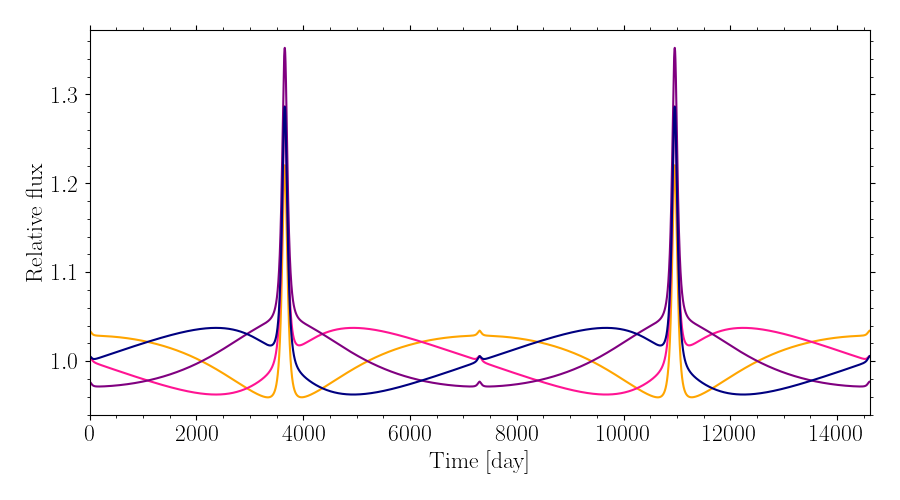

In [45]:
# Show final model
t = time.value / 86400
plt.figure(figsize=(9,5))
plt.plot(t, flux_w000, '-', c='orange')
plt.plot(t, flux_w090, '-', c='deeppink')
plt.plot(t, flux_w180, '-', c='purple')
plt.plot(t, flux_w270, '-', c='navy')
plt.xlim(0, t[-1])
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.tight_layout();

In [1]:
# # PLOT FOR THESIS COVER
# # Combined model (Beaming + QSO varibility)
# flux = flux_beam * flux_red * flux_lens
# # Plotting the combined model
# fig = plt.figure(figsize=(3.18,1.6))
# plt.plot(time.to('d'), flux, color='w', lw=0.8)
# plt.xlim(0, time.to('d').value[-1])
# plt.tight_layout()
# plt.xticks([])
# plt.yticks([])
# plt.axis('off')
# # Save figure
# tdir = '/lhome/nicholas/Nextcloud/thesis/image'
# fig.savefig(f'{tdir}/lightcurve_smbhb.png', bbox_inches='tight', dpi=300, transparent=True)